In [1]:
"""
TO BE ADDED:

- Feature importance


Models:
Neural network models
https://medium.com/@nandiniverma78988/neural-network-regression-implementation-and-visualization-in-python-d5893713ed79

"""


# Data wrangling libraries
import pandas as pd
import numpy as np
import time

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_predict, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.decomposition import PCA

# Regression libraries
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LogisticRegression
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor


# Metric libraries
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



pd.set_option('display.max_columns', None) # display all columns
pd.set_option('display.expand_frame_repr', False) # print all columns and in the same line
pd.set_option('display.max_colwidth', None) # display the full content of each cell
pd.set_option('display.float_format', lambda x: '%.3f' %x) # floats to be displayed with 3 decimal places

In [2]:
df = pd.read_csv("data/data_cleaned.csv")
#df = df.drop(columns=['postcode'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38979 entries, 0 to 38978
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   bedroomcount               38979 non-null  float64
 1   habitablesurface           38979 non-null  float64
 2   haslift                    38979 non-null  int64  
 3   hasgarden                  38979 non-null  int64  
 4   hasswimmingpool            38979 non-null  int64  
 5   hasterrace                 38979 non-null  int64  
 6   price                      38979 non-null  float64
 7   hasparking                 38979 non-null  int64  
 8   epcscore_encoded           38979 non-null  float64
 9   buildingcondition_encoded  38979 non-null  float64
 10  region_Brussels            38979 non-null  float64
 11  region_Flanders            38979 non-null  float64
 12  region_Wallonia            38979 non-null  float64
 13  type_encoded               38979 non-null  int

In [3]:
# Set the datasets for analysis and the target variable
df_all = df
df_hs = df[df['type_encoded'] == 1]  # Houses
df_apt = df[df['type_encoded'] == 0]  # Apartments

target = 'price'

In [4]:
numVar = [target, 'bedroomcount', 'habitablesurface']
numVar

['price', 'bedroomcount', 'habitablesurface']

In [5]:
def makeBoxplot(var):

    plt.figure(figsize=(5, 2))
    plt.boxplot(df[var], vert=False, patch_artist=True, boxprops=dict(alpha=0.8),
                medianprops=dict(color='white'))

    plt.title(f'Boxplot of {var.capitalize()}', fontsize=14, fontweight='bold')
    plt.ylabel("")
    plt.xlabel("")
    plt.yticks([])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


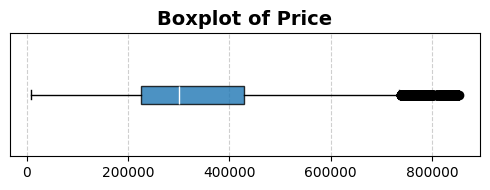

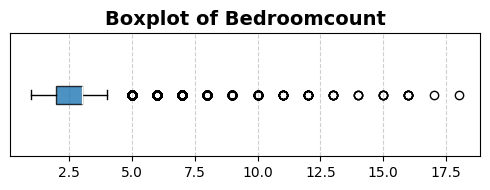

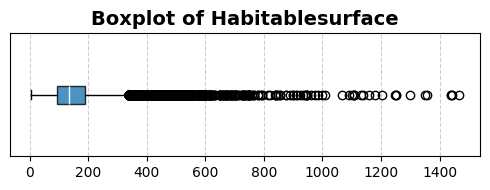

In [6]:
for var in numVar:
    makeBoxplot(var)

In [7]:
def splitDF(n, df, target):
    """
    Function to split the dataframe based on the requirements on the regression model we need to run
    """
    
    # First split: isolate the target variable
    y = df[target]
    X = df.drop([target], axis=1)
    
    # Second split: train and test as needed to run cross_val_predict
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

    # Further split training: training and validation sets for early stopping
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=123)
   
    if n == 1:
        return X, y
    
    elif n == 2:
        return X_train_full, y_train_full, X_test, y_test

    elif n == 3:
        return X_test, X_train, X_val, y_test, y_train, y_val
    
    else:
        raise ValueError(f"Invalid mode n={n}. Must be 1, 2 or 3.")



In [8]:
def regResults(df, obs, name, y_true, y_pred):
    """
    Function to return 
    """
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Return a dictionary with the metrics
    return {
        "Dataset": df,
        "Observations": obs,
        "Model": name,
        "R² Score": r2,
        "MAE": mae,
        "RMSE": rmse
    }


In [9]:
def plotPredictions(df, name, y_true, y_pred):
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], '--r')
    plt.title(f"{name} - {df} — Predicted vs Actual")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# REGRESSION MODELS

In [10]:
def runModels(df, obs, models, cv, results_df=None):
    """
    Funtion to run the whole set of models with their default parameters.
    It tracks runtime and stores evaluation metrics for each model.
    The function:
    - split the dataframe
    - loop through all the models
    - applies scaling to linear models
    - returns a dataframe with the results for each model

    Parameters:
    - df: DataFrame
    - obs: string quoting which features we are using
    - models: dict of model names
    - cv: cross-validation object

    Returns:
    - results_df: DataFrame with performance metrics and runtime for each model
    """

    # Isolate the target variable
    X, y = splitDF(1, df, target)

    # Initiate a list to save the results
    results = []

    # Loop through the models
    for model_name, model in models.items():

        start = time.time()

        # Apply scaling to linear models
        if model_name in ["Linear", "Ridge", "Lasso", "ElasticNet"]:
            pipeline = make_pipeline(StandardScaler(), model)
        else:
            pipeline = make_pipeline(model)

        # Predict using cross-validation
        y_pred = cross_val_predict(pipeline, X, y, cv=cv)

        end = time.time()
        runtime_min = round((end - start) / 60, 2)

        # Update the results list
        result = regResults("All properties", obs, model_name, y, y_pred)
        result["Runtime (min)"] = runtime_min
        results.append(result)
            
    # Create and return a dataframe with the results
    new_results_df = pd.DataFrame(results)
    if results_df is not None:
        results_df = pd.concat([results_df, new_results_df], ignore_index=True)
    else:
        results_df = new_results_df

    return results_df


In [11]:
# Set 10-Fold CV
cv = KFold(n_splits=10, shuffle=True, random_state=123)

# Declare the regression models with default parameters
models = { 
    # with default parameters
    "Linear": LinearRegression(),
    "LightGBM": LGBMRegressor(random_state=123, verbosity=-1),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(random_state=123),
    "Random Forest": RandomForestRegressor(random_state=123),
    "Gradient Boosting": GradientBoostingRegressor(random_state=123),
    "XGBoost": XGBRegressor(random_state=123),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=123),
    "AdaBoost": AdaBoostRegressor(random_state=123),
    "KNN": KNeighborsRegressor()

    # SVR model omitted as they take very long to process
    # "SVR Linear": SVR(kernel='linear'),
    # "SVR Polynomial": SVR(kernel='poly'),
    # "SVR Radial Basis Func.": SVR(kernel='rbf')
}


In [12]:
# Run the models and save the results
results_df = runModels(df_all, "All features", models, cv)
results_df = results_df.sort_values("R² Score", ascending=False)

print("\nSummary of Regression Results:")
print(results_df)


Summary of Regression Results:
           Dataset  Observations              Model  R² Score        MAE       RMSE  Runtime (min)
9   All properties  All features           CatBoost     0.752  58513.997  82171.509          1.420
8   All properties  All features            XGBoost     0.742  59572.737  83897.211          0.100
1   All properties  All features           LightGBM     0.739  60527.585  84374.139          0.100
6   All properties  All features      Random Forest     0.722  61779.345  87044.943          3.210
7   All properties  All features  Gradient Boosting     0.682  68355.805  93138.984          0.770
2   All properties  All features              Ridge     0.517  85015.411 114652.538          0.010
3   All properties  All features              Lasso     0.517  85015.348 114652.546          0.020
0   All properties  All features             Linear     0.517  85015.371 114652.547          0.010
11  All properties  All features                KNN     0.509  84824.713 1156

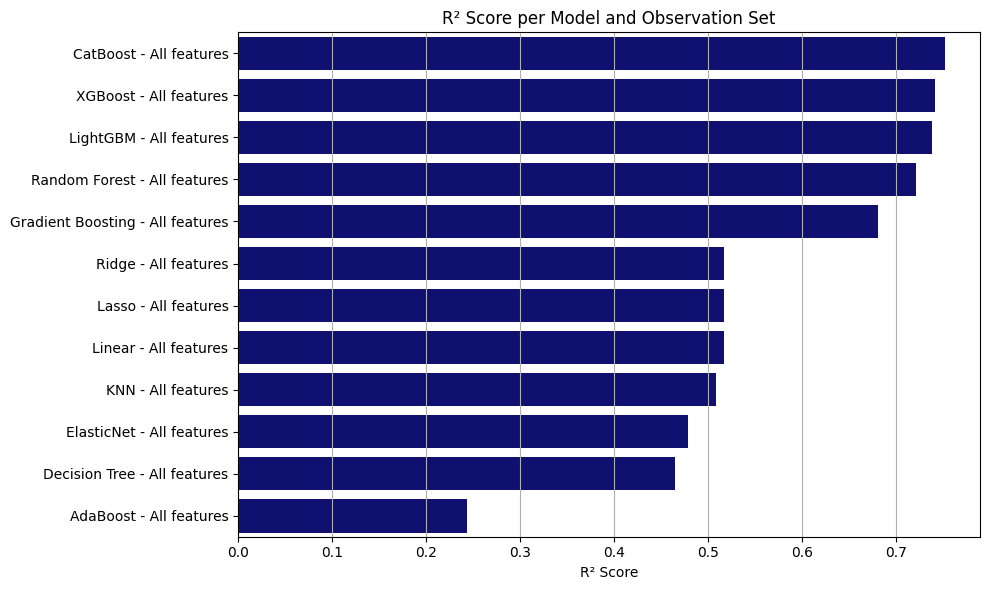

In [13]:
def resultPlot(results_df):
    
    # Create combined label for plotting
    results_df = results_df.copy()  # avoid modifying original
    results_df["Model + Obs"] = results_df["Model"] + " - " + results_df["Observations"]

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=results_df,
        y="Model + Obs", x="R² Score",
        color="navy"
    )

    plt.title("R² Score per Model and Observation Set")
    plt.xlabel("R² Score")
    plt.ylabel("")
    plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()


resultPlot(results_df)

In [14]:
# Run the models and save the results
df_all['price'] = np.log1p(df_all['price'])

results_df = runModels(df_all, "All feat. + y log", models, cv, results_df=results_df)
results_df = results_df.sort_values("R² Score", ascending=False)

print("\nSummary of Regression Results:")
print(results_df)


Summary of Regression Results:
           Dataset       Observations              Model  R² Score        MAE       RMSE  Runtime (min)
15  All properties  All feat. + y log              Lasso    -0.000      0.392      0.491          0.010
16  All properties  All feat. + y log         ElasticNet    -0.000      0.392      0.491          0.010
11  All properties       All features           AdaBoost     0.244 125049.934 143537.414          0.340
10  All properties       All features      Decision Tree     0.465  83569.104 120755.374          0.040
9   All properties       All features         ElasticNet     0.479  89834.433 119153.689          0.010
8   All properties       All features                KNN     0.509  84824.713 115677.196          0.030
7   All properties       All features             Linear     0.517  85015.371 114652.547          0.010
6   All properties       All features              Lasso     0.517  85015.348 114652.546          0.020
5   All properties       All fea

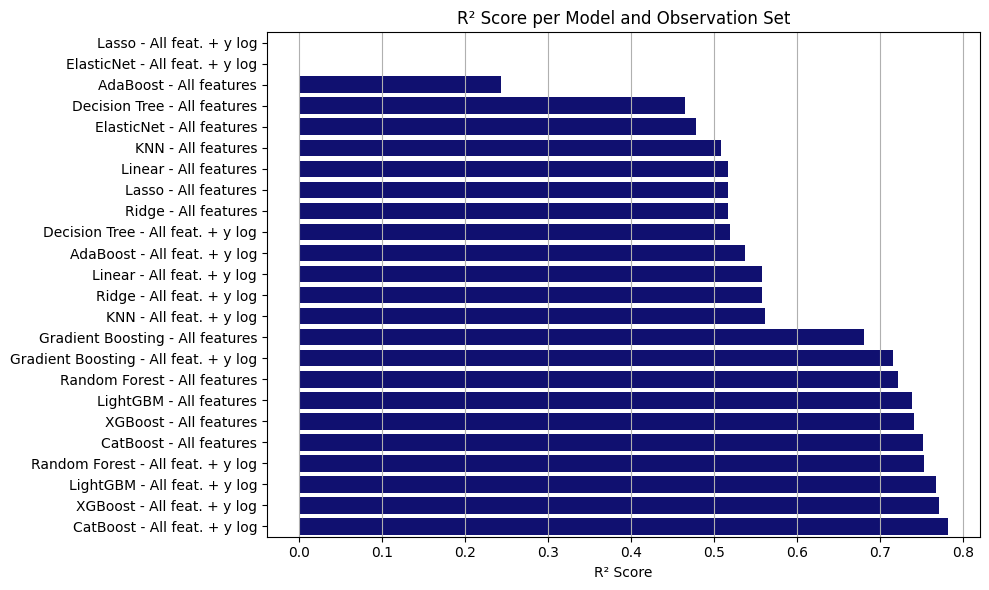

In [15]:
resultPlot(results_df)

Conclusions after the first round:

- Putting price in log scale performs better
- CatBoost, LightGBM and XGBoost models perform the best
- Random Forest also has good results, but performs worse (run time triples the other models)

We will then develop these 3 best models using price in log scale

In [16]:
results_1stRound = results_df
results_df = results_df.sort_values("RMSE", ascending=True).head(3)
results_df

,Dataset,Observations,Model,R² Score,MAE,RMSE,Runtime (min)
21,All properties,All feat. + y log,CatBoost,0.782,0.173,0.229,1.430
20,All properties,All feat. + y log,XGBoost,0.772,0.177,0.234,0.060
13,All properties,All feat. + y log,LightGBM,0.767,0.180,0.237,0.040


# TUNING XGBOOST

In [17]:
def XGBoost_withRandomS(df_all, obs, target):

    # Split data into train and test as needed to run cross_val_predict
    X_train_full, y_train_full, X_test, y_test = splitDF(2, df_all, target)

    # Set hyperparameter grid
    xgb_params = {
        'depth': [4, 6, 8, 10],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        'l2_leaf_reg': [1, 3, 5, 7, 9],
        'bagging_temperature': [0, 0.2, 0.5, 1],
        'iterations': [100, 500, 1000, 1500]
    }

    # Initialize model
    xgb_model = XGBRegressor(objective='reg:squarederror', eval_metric='rmse', random_state=123)

    # Tune hyperparameters
    xgb_search = RandomizedSearchCV(
        xgb_model, xgb_params,
        n_iter=10, cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1, verbose=1,
        random_state=123
    )

    xgb_search.fit(X_train_full, y_train_full)

    # Extract and print best parameters
    best_xgb_params = xgb_search.best_params_
    print(f"\nBest Hyperparameters for XGBoost:")
    for param, value in best_xgb_params.items():
        print(f"\t{param}: {value}")

    # Predict on test set using the best model
    best_xgb = xgb_search.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)


    # Predict on test set using the best model
    best_xgb = xgb_search.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)

    newResult = regResults("All properties", obs, "XGBoost", y_test, y_pred_xgb)
    return newResult



In [18]:
start = time.time()
newResult = XGBoost_withRandomS(df_all, "RandomizedSearchCV", target)
end = time.time()

code_run = (end - start) / 60
newResult["Runtime (min)"] = code_run

print("\nSummary of Regression Results:")
results_df = pd.concat([results_df, pd.DataFrame([newResult])], ignore_index=True)
print(results_df.sort_values(by=["Dataset", "RMSE"]))


Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\bljor\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:59:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "bagging_temperature", "depth", "iterations", "l2_leaf_reg" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Hyperparameters for XGBoost:
	learning_rate: 0.2
	l2_leaf_reg: 3
	iterations: 500
	depth: 8
	bagging_temperature: 1

Summary of Regression Results:
          Dataset        Observations     Model  R² Score   MAE  RMSE  Runtime (min)
0  All properties   All feat. + y log  CatBoost     0.782 0.173 0.229          1.430
1  All properties   All feat. + y log   XGBoost     0.772 0.177 0.234          0.060
2  All properties   All feat. + y log  LightGBM     0.767 0.180 0.237          0.040
3  All properties  RandomizedSearchCV   XGBoost     0.770 0.177 0.237          0.354


# TUNNING CATBOOST

In [19]:
def CatBoost_withRandomS(df_all, obs, target):

    # Split data into train and test as needed to run cross_val_predict
    cat_features = df_all.select_dtypes(include=['object']).columns.tolist()
    X_train_full, y_train_full, X_test, y_test = splitDF(2, df_all, target)

    # Set hyperparameter grid
    cat_params = {
        'depth': [4, 6, 8, 10],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        'l2_leaf_reg': [1, 3, 5, 7, 9],
        'bagging_temperature': [0, 0.2, 0.5, 1],
        'iterations': [100, 500, 1000, 1500]    
        }

    # Initialize model
    cat_model = CatBoostRegressor(eval_metric='RMSE', cat_features=cat_features, verbose=0, random_state=123)

    # Tune hyperparameters
    cat_search = RandomizedSearchCV(
        cat_model, cat_params,
        n_iter=10, cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1, verbose=0,
        random_state=123
    )

    cat_search.fit(X_train_full, y_train_full, cat_features=cat_features)

    # Extract and print best parameters
    best_cat_params = cat_search.best_params_
    print(f"\nBest Hyperparameters for Catoost:")
    for param, value in best_cat_params.items():
        print(f"\t{param}: {value}")

    # Predict on test set using the best model
    best_cat = cat_search.best_estimator_
    y_pred_cat = best_cat.predict(X_test)


    # Predict on test set using the best model
    best_cat = cat_search.best_estimator_
    y_pred_cat = best_cat.predict(X_test)

    newResult = regResults("All properties", obs, "CatBoost", y_test, y_pred_cat)
    return newResult



In [20]:
start = time.time()
newResult = CatBoost_withRandomS(df_all, "RsearchCV", target)
end = time.time()

code_run = (end - start) / 60
newResult["Runtime (min)"] = code_run

print("\nSummary of Regression Results:")
results_df = pd.concat([results_df, pd.DataFrame([newResult])], ignore_index=True)
print(results_df.sort_values(by=["Dataset", "RMSE"]))



Best Hyperparameters for Catoost:
	learning_rate: 0.2
	l2_leaf_reg: 3
	iterations: 1000
	depth: 4
	bagging_temperature: 0

Summary of Regression Results:
          Dataset        Observations     Model  R² Score   MAE  RMSE  Runtime (min)
0  All properties   All feat. + y log  CatBoost     0.782 0.173 0.229          1.430
1  All properties   All feat. + y log   XGBoost     0.772 0.177 0.234          0.060
4  All properties           RsearchCV  CatBoost     0.775 0.175 0.235          8.202
2  All properties   All feat. + y log  LightGBM     0.767 0.180 0.237          0.040
3  All properties  RandomizedSearchCV   XGBoost     0.770 0.177 0.237          0.354


# TUNNING LIGHTGBM

In [21]:
def lightGBM_withRandomS(df_all, obs, target):

    # Split data into train and test as needed to run cross_val_predict
    cat_features = df_all.select_dtypes(include=['object']).columns.tolist()
    X_train_full, y_train_full, X_test, y_test = splitDF(2, df_all, target)

    # Set hyperparameter grid
    lgb_params = {
    'num_leaves': [31, 50, 70, 90, 120],
    'max_depth': [-1, 5, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 500, 1000, 1500],
    'min_data_in_leaf': [10, 20, 40, 60],
    'feature_fraction': [0.6, 0.8, 1.0],
    'bagging_fraction': [0.6, 0.8, 1.0],
    'bagging_freq': [0, 1, 5, 10],
    'lambda_l1': [0, 0.1, 0.5, 1.0],
    'lambda_l2': [0, 0.1, 0.5, 1.0]
    }

    # Initialize model
    lgb_model = LGBMRegressor(random_state=123)

    # Tune hyperparameters
    lgb_search = RandomizedSearchCV(
        lgb_model, lgb_params,
        n_iter=30, cv=3,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1, verbose=0,
        random_state=123
    )

    lgb_search.fit(X_train_full, y_train_full, categorical_feature=cat_features)

    # Extract and print best parameters
    best_lgb_params = lgb_search.best_params_
    print(f"\nBest Hyperparameters for lgboost:")
    for param, value in best_lgb_params.items():
        print(f"\t{param}: {value}")

    # Predict on test set using the best model
    best_lgb = lgb_search.best_estimator_
    y_pred_lgb = best_lgb.predict(X_test)


    # Predict on test set using the best model
    best_lgb = lgb_search.best_estimator_
    y_pred_lgb = best_lgb.predict(X_test)

    newResult = regResults("All properties", obs, "lgbBoost", y_test, y_pred_lgb)
    return newResult



In [22]:
start = time.time()
newResult = CatBoost_withRandomS(df_all, "RsearchCV", target)
end = time.time()

code_run = (end - start) / 60
newResult["Runtime (min)"] = code_run

print("\nSummary of Regression Results:")
results_df = pd.concat([results_df, pd.DataFrame([newResult])], ignore_index=True)
print(results_df.sort_values(by=["Dataset", "RMSE"]))



Best Hyperparameters for Catoost:
	learning_rate: 0.2
	l2_leaf_reg: 3
	iterations: 1000
	depth: 4
	bagging_temperature: 0

Summary of Regression Results:
          Dataset        Observations     Model  R² Score   MAE  RMSE  Runtime (min)
0  All properties   All feat. + y log  CatBoost     0.782 0.173 0.229          1.430
1  All properties   All feat. + y log   XGBoost     0.772 0.177 0.234          0.060
4  All properties           RsearchCV  CatBoost     0.775 0.175 0.235          8.202
5  All properties           RsearchCV  CatBoost     0.775 0.175 0.235          6.299
2  All properties   All feat. + y log  LightGBM     0.767 0.180 0.237          0.040
3  All properties  RandomizedSearchCV   XGBoost     0.770 0.177 0.237          0.354


# MOST IMPORTANT FEATURES

C:\Users\bljor\AppData\Local\Temp\ipykernel_26284\3297123190.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=catboost_importance, x="Importance", y="Feature", palette="viridis")


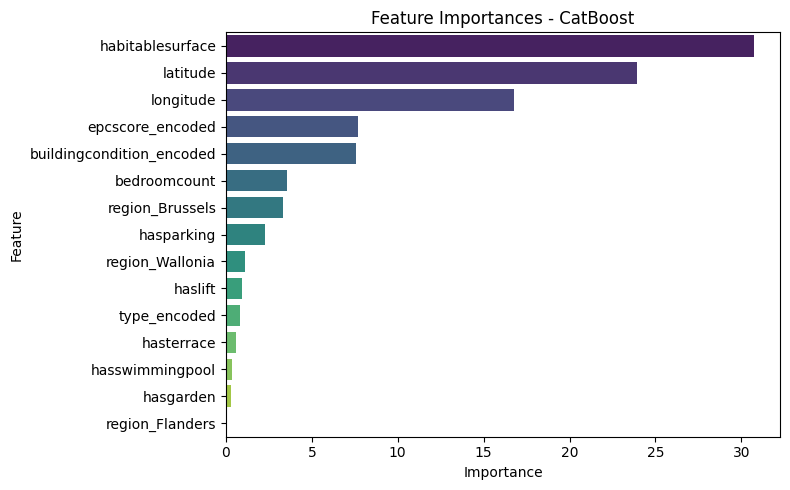

In [30]:
X, y = splitDF(1, df_all, target)

model = CatBoostRegressor(verbose=0, random_state=123)
model.fit(X, y)

# Get feature importances
importances = model.get_feature_importance()
feature_names = X.columns

# Create DataFrame
catboost_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Plot top 10 features
plt.figure(figsize=(8, 5))
sns.barplot(data=catboost_importance, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importances - CatBoost")
plt.tight_layout()
plt.show();



In [ ]:
# Set the datasets for analysis
df_all = df_cleaned
df_hs = df_cleaned[df_cleaned['type_encoded'] == 1]  # Houses
df_apt = df_cleaned[df_cleaned['type_encoded'] == 0]  # Apartments

datasets = {
    "All Properties": df_all,
    "Only Houses": df_hs,
    "Only Apartments": df_apt
}

results_df = runModels(datasets, "No outliers", models, cv)
print("\nSummary of Regression Results:")
print(results_df.sort_values(by=["Dataset", "RMSE"]))



In [ ]:
# PCA
# n_components=2	Keep only the top 2 components
# n_components=0.95	Keep enough components to explain 95% of the variance
# n_components='mle'	Let PCA choose the optimal number using MLE (only for full SVD)
# Omitted	Keep all components (just rotates them)

# Dictionary to hold PCA-transformed datasets
datasets_pca = {}

for name, df in datasets.items():
    
    X, y = splitDF(df, target)

    # Standardize predictors
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply PCA
    pca = PCA(n_components=0.95) # keep 95% variance
    X_pca = pca.fit_transform(X_scaled)

    # Create a DataFrame with principal components
    df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
    df_pca[target] = y.values  # add target column back

    # Save transformed dataset
    datasets_pca[name] = df_pca

# Run models with PCA
results_df = runModels(datasets_pca, "PCA", models, cv)

print("\nSummary of Regression Results:")
print(results_df.sort_values(by=["Dataset", "RMSE"]))

In [ ]:
r = results_df.sort_values(by=["Dataset", "RMSE"])
r.to_csv('Regression_scores.csv', index=False)